# Notebook to perform RFE and analyze the results


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
from trait_prediction.main import (
    FeatureIndex,
    FeatureInput,
    PhenotypeIndex,
    PhenotypeInput,
    Feature,
    FeatureSet,
    Phenotype,
    PhenotypeSet,
    DataSet,
)

In [3]:
def index_format_func(x):
    return (
        x.strip()
        .split("?")[-1]
        .removesuffix(".RAST")
        .removesuffix(".fna")
        .removeprefix("g")
    )

In [4]:
PHENOTYPES_SUBSET = [
    "Alanine",
    "Arginine",
    "Cellobiose",
    "Fructose",
    "Galactose",
    "Galacturonic-Acid",
    "Glucose",
    "Glycerol",
    "Histidine",
    "Maltose",
    "Mannitol",
    "Mannose",
    "Serine",
    "Sucrose",
    # "Trehalose",
    "m-Inositol",
]

In [5]:
PHENOTYPES_SUBSET = [
    "Galactose",
    "Histidine",
    "Serine",
]

## Load data


### Load feature data (ATleaf kofam features (full))


In [6]:
def load_feature(feature_file: Path) -> Feature:
    name = feature_file.parent.stem
    findex = FeatureIndex(name=name, ftype="binary", dtype="uint8")
    finput = FeatureInput(
        path=feature_file,
        findex=findex,
        index_format_func=index_format_func,
    )
    feature = Feature.read_data(finput)
    return feature

In [7]:
features = []
for dataset_name in ["atleaf", "marine"]:
    feature_file = Path(f"../data/interim/features/{dataset_name}/kofam.tsv")
    feature = load_feature(feature_file)
    features.append(feature)
feature_set = FeatureSet(features)

### Load phenotype data (ATleaf X phenotype)


In [8]:
def load_phenotype(phenotype_file: Path) -> Phenotype:
    name = phenotype_file.stem
    category = phenotype_file.parent.stem
    pindex = PhenotypeIndex(name=name, category=category)
    pinput = PhenotypeInput(
        path=phenotype_file, pindex=pindex, index_format_func=index_format_func
    )
    phenotype = Phenotype.read_data(pinput)
    return phenotype

In [9]:
phenotypes = []
for dataset_name in ["atleaf", "marine"]:
    for phenotype_name in PHENOTYPES_SUBSET:
        phenotype_file = Path(
            f"../data/processed/phenotypes/{dataset_name}/{phenotype_name}.tsv"
        )
        phenotype = load_phenotype(phenotype_file)
        phenotypes.append(phenotype)
phenotype_set = PhenotypeSet(phenotypes)

In [10]:
dataset = DataSet(phenotype_set, feature_set)
dataset

DataSet(phenotype_set=PhenotypeSet (n=6), feature_set=FeatureSet (n=2))

In [11]:
def get_xy(
    dataset: DataSet, phenotype_name: str, feature_name: str
) -> tuple[pd.DataFrame, pd.Series]:
    pindex = PhenotypeIndex(name=phenotype_name, category=feature_name)
    findex = FeatureIndex(name=feature_name, ftype="binary", dtype="uint8")
    phenotype, feature = dataset.get_data(pindex, findex)
    x = feature.feature_data
    y = phenotype.phenotype_data
    return x, y

## Perform validation using RandomForestClassifier with different random seeds


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, matthews_corrcoef

Do we arrive at the same top features if we use the same training data but with different random seeds?


In [13]:
def train_validate(X_train, y_train, X_test, y_test, random_state):
    model = RandomForestClassifier(
        n_estimators=1000,
        random_state=random_state,
        n_jobs=-1,
        max_features=None,  # type: ignore
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    importances = model.feature_importances_
    feature_names = X_train.columns
    importance_df = pd.Series(importances, index=feature_names)
    importance_df.sort_values(ascending=False, inplace=True)
    top_features = list(importance_df.head(10).index)
    scores = {
        "acc": accuracy_score(y_test, y_pred),
        "bacc": balanced_accuracy_score(y_test, y_pred),
        "mcc": matthews_corrcoef(y_test, y_pred),
    }
    return scores, top_features

In [14]:
def score_same_data_diff_model(
    dataset: DataSet,
    phenotype_name: str,
    feature_name: str,
    feature_columns: list[str] | None = None,
    test_dataset_name: str | None = None,
) -> pd.DataFrame:
    X, y = get_xy(dataset, phenotype_name, feature_name)
    if feature_columns is not None:
        X = X.loc[:, feature_columns]
    # Same random state here
    if test_dataset_name is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        X_train, y_train = X, y
        X_test, y_test = get_xy(dataset, phenotype_name, test_dataset_name)
        missing_cols = X_train.columns.difference(X_test.columns)
        X_test.loc[:, missing_cols] = 0
        X_test = X_test.loc[:, list(X_train.columns)]
    score_data = []
    # Different random states for clf
    for random_state in range(1, 100, 10):
        score, features = train_validate(
            X_train, y_train, X_test, y_test, random_state=random_state
        )
        score["random_state"] = random_state
        score["features"] = features
        score_data.append(score)
    score_df = pd.DataFrame(score_data)
    return score_df

In [15]:
def score_diff_data_same_model(
    dataset: DataSet,
    phenotype_name: str,
    feature_name: str,
    feature_columns: list[str] | None = None,
) -> pd.DataFrame:
    X, y = get_xy(dataset, phenotype_name, feature_name)
    if feature_columns is not None:
        X = X.loc[:, feature_columns]
    score_data = []
    for random_state in range(1, 100, 10):
        # Different random states for split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y
        )
        # Same random state here
        score, features = train_validate(
            X_train, y_train, X_test, y_test, random_state=42
        )
        score["random_state"] = random_state
        score["features"] = features
        score_data.append(score)
    score_df = pd.DataFrame(score_data)
    return score_df

In [16]:
no_rfe_scores = []
for dataset_name in ["atleaf", "marine"]:
    for phenotype_name in PHENOTYPES_SUBSET:
        for _type in ["ddsm", "sddm"]:
            if _type == "ddsm":
                _func = score_diff_data_same_model
            elif _type == "sddm":
                _func = score_same_data_diff_model
            else:
                raise ValueError("Invalid type")
            score = _func(dataset, phenotype_name, dataset_name)
            score["phenotype"] = phenotype_name
            score["dataset"] = dataset_name
            score["rfe"] = "no_rfe"
            score["type"] = _type
            no_rfe_scores.append(score)

In [17]:
no_rfe_scores_df = pd.concat(no_rfe_scores)

## RFE analysis


In [18]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [19]:
# FIXME: This should be tested using only the held-out validation set
def perform_rfe(
    dataset, phenotype_name, feature_name, random_state
) -> tuple[RFECV, list[str]]:
    X, y = get_xy(dataset, phenotype_name, feature_name)
    model = RandomForestClassifier(
        n_estimators=1000,
        random_state=random_state,
        n_jobs=1,
        max_features=None,  # type: ignore
    )
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=random_state)
    rfe_cv = RFECV(
        model,
        step=0.1,
        min_features_to_select=100,
        cv=cv,  # type: ignore
        scoring="matthews_corrcoef",
        verbose=0,
        n_jobs=-1,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )
    rfe_cv.fit(X_train, y_train)
    # rfe_cv.fit(X, y)
    feature_columns = X.columns[rfe_cv.ranking_ == 1]
    return rfe_cv, feature_columns

In [20]:
rfe_scores = []
for dataset_name in ["atleaf", "marine"]:
    for phenotype_name in PHENOTYPES_SUBSET:
        rfe_cv, feature_columns = perform_rfe(
            dataset, phenotype_name, dataset_name, random_state=100
        )
        for _type in ["ddsm", "sddm"]:
            if _type == "ddsm":
                _func = score_diff_data_same_model
            elif _type == "sddm":
                _func = score_same_data_diff_model
            else:
                raise ValueError("Invalid type")
            score = _func(
                dataset, phenotype_name, dataset_name, feature_columns=feature_columns
            )
            score["phenotype"] = phenotype_name
            score["dataset"] = dataset_name
            score["rfe"] = "rfe"
            score["type"] = _type
            rfe_scores.append(score)

In [21]:
rfe_scores_df = pd.concat(rfe_scores)

In [22]:
scores_df = pd.concat([no_rfe_scores_df, rfe_scores_df])

## Visualization


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
scores_df

,acc,bacc,mcc,random_state,features,phenotype,dataset,rfe,type
0,0.951220,0.916667,0.882933,1,"[K01443, K14449, K03829, K04073, K07675, K0353...",Galactose,atleaf,no_rfe,ddsm
1,0.926829,0.923851,0.828861,11,"[K01443, K14449, K07675, K03534, K09760, K0579...",Galactose,atleaf,no_rfe,ddsm
2,0.926829,0.923851,0.828861,21,"[K01443, K03534, K14449, K04073, K12658, K0202...",Galactose,atleaf,no_rfe,ddsm
3,0.878049,0.840517,0.699362,31,"[K01443, K03534, K14449, K07675, K02020, K0382...",Galactose,atleaf,no_rfe,ddsm
4,0.878049,0.864943,0.713663,41,"[K14449, K01443, K07675, K22552, K05966, K1722...",Galactose,atleaf,no_rfe,ddsm
...,...,...,...,...,...,...,...,...,...
5,0.771429,0.767974,0.554371,51,"[K10111, K18893, K07638, K00060, K07257, K0899...",Serine,marine,rfe,sddm
6,0.800000,0.797386,0.606788,61,"[K10111, K07638, K18893, K00060, K07257, K0691...",Serine,marine,rfe,sddm
7,0.800000,0.797386,0.606788,71,"[K10111, K07638, K18893, K00060, K07257, K0691...",Serine,marine,rfe,sddm
8,0.800000,0.797386,0.606788,81,"[K10111, K07638, K18893, K00060, K07257, K0899...",Serine,marine,rfe,sddm


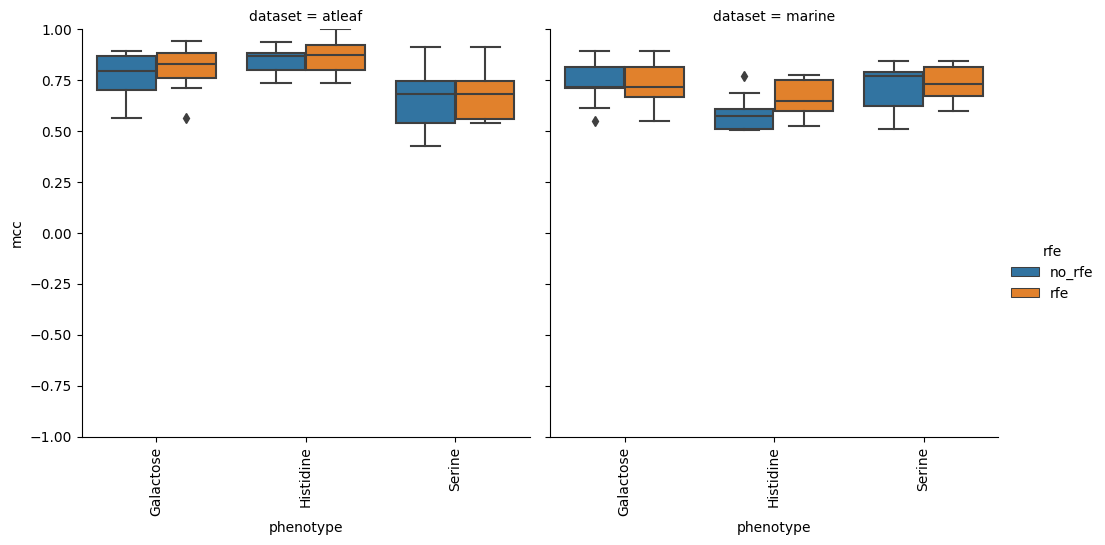

In [25]:
g = sns.catplot(
    data=scores_df[scores_df["type"] == "ddsm"],
    y="mcc",
    x="phenotype",
    hue="rfe",
    kind="box",
    # col="type",
    col="dataset",
)
plt.ylim(-1, 1)
for ax in g.axes.flat:
    ax.set_ylim(-1, 1)
    # ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

In [26]:
def get_num_common_features(grp) -> int:
    common_features = set.intersection(*(set(f) for f in grp["features"]))
    return len(common_features)

In [27]:
common_features_df = (
    scores_df.groupby(["dataset", "phenotype", "rfe", "type"])
    .apply(get_num_common_features)
    .reset_index()
)
common_features_df.rename(columns={0: "num_common_features"}, inplace=True)
common_features_df

/tmp/ipykernel_753942/2134571312.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_num_common_features)


,dataset,phenotype,rfe,type,num_common_features
0,atleaf,Galactose,no_rfe,ddsm,2
1,atleaf,Galactose,no_rfe,sddm,8
2,atleaf,Galactose,rfe,ddsm,2
3,atleaf,Galactose,rfe,sddm,5
4,atleaf,Histidine,no_rfe,ddsm,3
5,atleaf,Histidine,no_rfe,sddm,7
6,atleaf,Histidine,rfe,ddsm,3
7,atleaf,Histidine,rfe,sddm,7
8,atleaf,Serine,no_rfe,ddsm,0
9,atleaf,Serine,no_rfe,sddm,7


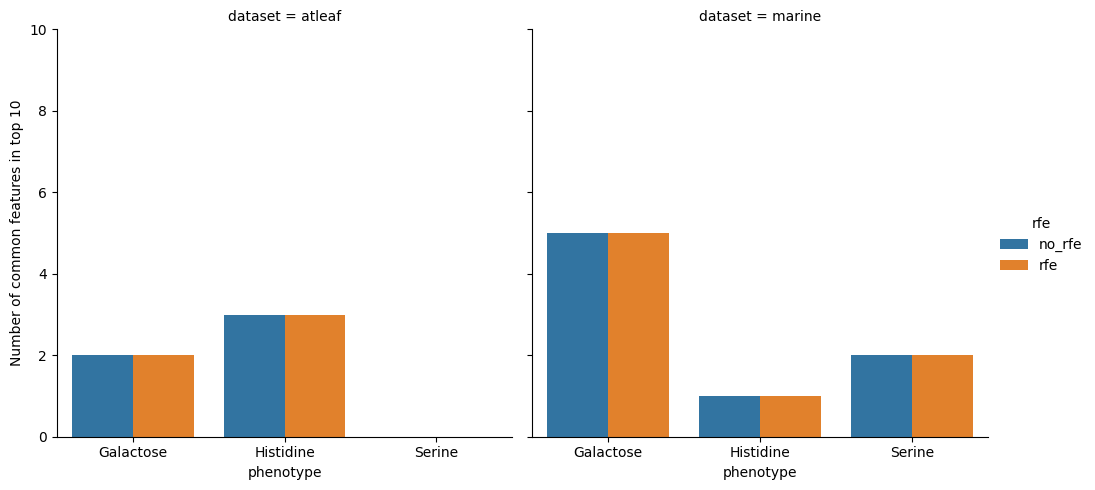

In [28]:
g = sns.catplot(
    data=common_features_df[common_features_df["type"] == "ddsm"],
    y="num_common_features",
    x="phenotype",
    hue="rfe",
    kind="bar",
    # col="type",
    col="dataset",
)
plt.ylim(0, 10)
for ax in g.axes.flat:
    ax.set_ylabel("Number of common features in top 10")

### Common between RFE and non-RFE

In [38]:
def get_common_features(grp) -> set[str]:
    common_features = set.intersection(*(set(f) for f in grp["features"]))
    return common_features

In [44]:
common_features_set_df = (
    scores_df.groupby(["dataset", "phenotype", "rfe", "type"])
    .apply(get_common_features)
    .reset_index()
)
common_features_set_df.rename(columns={0: "features"}, inplace=True)
common_features_set_df["num_features"] = common_features_set_df["features"].apply(len)
common_features_set_df

/tmp/ipykernel_753942/1190982042.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_common_features)


,dataset,phenotype,rfe,type,features,num_features
0,atleaf,Galactose,no_rfe,ddsm,"{K14449, K01443}",2
1,atleaf,Galactose,no_rfe,sddm,"{K14449, K00883, K03519, K03534, K09760, K0144...",8
2,atleaf,Galactose,rfe,ddsm,"{K14449, K01443}",2
3,atleaf,Galactose,rfe,sddm,"{K14449, K03519, K03534, K01443, K01631}",5
4,atleaf,Histidine,no_rfe,ddsm,"{K09975, K01031, K01032}",3
5,atleaf,Histidine,no_rfe,sddm,"{K22733, K09975, K18815, K15868, K15066, K0311...",7
6,atleaf,Histidine,rfe,ddsm,"{K09975, K01031, K01032}",3
7,atleaf,Histidine,rfe,sddm,"{K22733, K09975, K18815, K15868, K15066, K0311...",7
8,atleaf,Serine,no_rfe,ddsm,{},0
9,atleaf,Serine,no_rfe,sddm,"{K03087, K09456, K18479, K13641, K05541, K0192...",7


In [45]:
common_features_set_df.groupby(["dataset", "phenotype", "type"]).apply(
    get_common_features
).reset_index()

/tmp/ipykernel_753942/3088546409.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  common_features_set_df.groupby(["dataset", "phenotype", "type"]).apply(get_common_features).reset_index()


,dataset,phenotype,type,0
0,atleaf,Galactose,ddsm,"{K14449, K01443}"
1,atleaf,Galactose,sddm,"{K14449, K03519, K03534, K01443, K01631}"
2,atleaf,Histidine,ddsm,"{K09975, K01031, K01032}"
3,atleaf,Histidine,sddm,"{K22733, K09975, K18815, K15868, K15066, K0311..."
4,atleaf,Serine,ddsm,{}
5,atleaf,Serine,sddm,"{K03087, K09456, K18479, K13641, K05541, K0192..."
6,marine,Galactose,ddsm,"{K01190, K01686, K07407, K01785, K02058}"
7,marine,Galactose,sddm,"{K01190, K01686, K07407, K01785, K25649, K02058}"
8,marine,Histidine,ddsm,{K09975}
9,marine,Histidine,sddm,"{K09975, K02282, K07461, K08642, K13787, K1678..."


### Verify cross-test performance imporvement of RFE


In [29]:
cross_test_scores = []
for train_dataset_name in ["atleaf", "marine"]:
    for test_dataset_name in ["atleaf", "marine"]:
        if train_dataset_name == test_dataset_name:
            continue
        for phenotype_name in PHENOTYPES_SUBSET:
            for rfe in ["no_rfe", "rfe"]:
                if rfe == "rfe":
                    rfe_cv, feature_columns = perform_rfe(
                        dataset, phenotype_name, train_dataset_name, random_state=100
                    )
                    score = score_same_data_diff_model(
                        dataset,
                        phenotype_name,
                        train_dataset_name,
                        feature_columns=feature_columns,
                        test_dataset_name=test_dataset_name,
                    )
                elif rfe == "no_rfe":
                    score = score_same_data_diff_model(
                        dataset,
                        phenotype_name,
                        train_dataset_name,
                        test_dataset_name=test_dataset_name,
                    )
                else:
                    raise ValueError("rfe must be either rfe or no_rfe")
                score["phenotype"] = phenotype_name
                score["train_dataset"] = train_dataset_name
                score["test_dataset"] = test_dataset_name
                score["rfe"] = rfe
                cross_test_scores.append(score)

In [30]:
cross_test_scores_df = pd.concat(cross_test_scores)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


Text(0.5, 1.0, 'Train dataset: marine | Test dataset: atleaf')

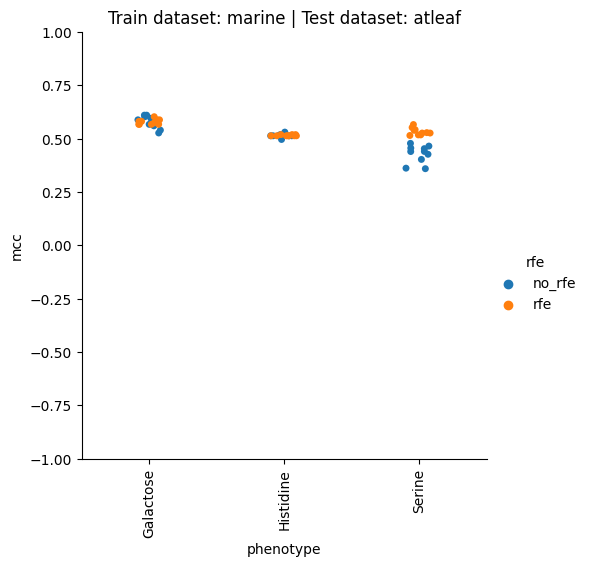

In [31]:
g = sns.catplot(
    data=cross_test_scores_df[(cross_test_scores_df.test_dataset == "atleaf")],
    y="mcc",
    x="phenotype",
    hue="rfe",
    kind="strip",
    # col="test_dataset",
    # row="train_dataset",
)
plt.ylim(-1, 1)
axes_to_remove = []
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    for label in ax.get_xticklabels():
        label.set_rotation(90)

for ax in axes_to_remove:
    g.fig.delaxes(ax)
plt.title("Train dataset: marine | Test dataset: atleaf")

In [32]:
def get_common_features(grp) -> set[str]:
    common_features = set.intersection(*(set(f) for f in grp["features"]))
    return common_features

In [33]:
cross_common_features_df = (
    cross_test_scores_df.groupby(["train_dataset", "phenotype", "rfe", "test_dataset"])
    .apply(get_common_features)
    .reset_index()
)
cross_common_features_df.rename(columns={0: "features"}, inplace=True)
cross_common_features_df

/tmp/ipykernel_753942/3158806456.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_common_features)


,train_dataset,phenotype,rfe,test_dataset,features
0,atleaf,Galactose,no_rfe,marine,"{K04073, K14449, K03519, K03534, K02020, K1614..."
1,atleaf,Galactose,rfe,marine,"{K04073, K14449, K03519, K03534, K02020, K01443}"
2,atleaf,Histidine,no_rfe,marine,"{K22733, K09975, K01032, K15868, K01031, K0262..."
3,atleaf,Histidine,rfe,marine,"{K22733, K09975, K01032, K15868, K01031, K0262..."
4,atleaf,Serine,no_rfe,marine,"{K03087, K18166, K05541, K01923, K05835, K0160..."
5,atleaf,Serine,rfe,marine,"{K03087, K18166, K05541, K01923, K05835, K0160..."
6,marine,Galactose,no_rfe,atleaf,"{K01190, K00849, K01686, K07407, K00864, K1011..."
7,marine,Galactose,rfe,atleaf,"{K01190, K00849, K01686, K07407, K00864, K1011..."
8,marine,Histidine,no_rfe,atleaf,"{K09975, K02282, K08642, K13787, K08151, K1678..."
9,marine,Histidine,rfe,atleaf,"{K09975, K02282, K08642, K13787, K08151, K1678..."


In [34]:
cross_test_common_features = (
    cross_common_features_df.groupby(["phenotype", "rfe"])
    .apply(get_num_common_features)
    .reset_index()
)
cross_test_common_features.rename(columns={0: "num_common_features"}, inplace=True)
cross_test_common_features

/tmp/ipykernel_753942/1424352421.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_num_common_features)


,phenotype,rfe,num_common_features
0,Galactose,no_rfe,0
1,Galactose,rfe,0
2,Histidine,no_rfe,1
3,Histidine,rfe,1
4,Serine,no_rfe,0
5,Serine,rfe,0


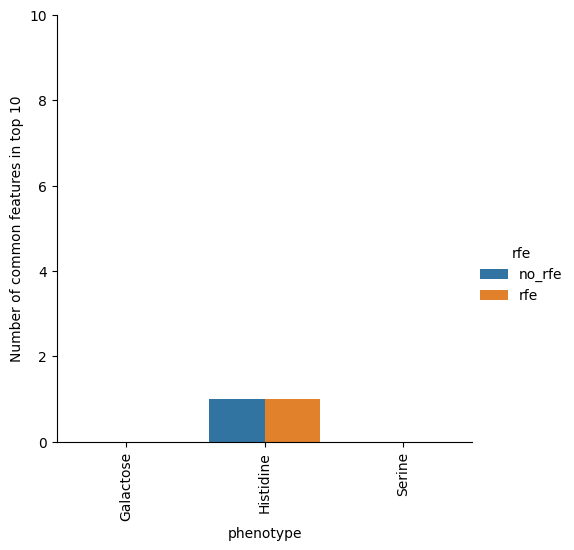

In [35]:
g = sns.catplot(
    data=cross_test_common_features,
    y="num_common_features",
    x="phenotype",
    hue="rfe",
    kind="bar",
    # col="test_dataset",
    # row="train_dataset",
)
plt.ylim(0, 10)
for ax in g.axes.flat:
    ax.set_ylabel("Number of common features in top 10")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

In [36]:
# # Saving the data
# output_dir = Path("../data/processed/rfe_results/")
# output_dir.mkdir(exist_ok=True)
# scores_df.to_csv(output_dir / "scores.tsv", sep="\t", index=False)
# cross_test_scores_df.to_csv(output_dir / "cross_test_scores.tsv", sep="\t", index=False)

## Try SelectFromModel

Ref: https://scikit-learn.org/1.5/modules/feature_selection.html#tree-based-feature-selection
